In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [ ]:
pd.set_option('display.max_columns', None)          # Show all columns
pd.set_option('display.width', None)                # Adjust width dynamically
pd.set_option('display.expand_frame_repr', False)   # Prevent column wrapping
warnings.filterwarnings('ignore')

# Get Dataset


In [ ]:
# Install the kagglehub library
!pip install --upgrade kagglehub -q

In [ ]:
import kagglehub
import os

# Dowload dataset
path = kagglehub.dataset_download("PROPPG-PPG/hourly-weather-surface-brazil-southeast-region")

# Create the link to file csv
file_path = os.path.join(path, "north.csv")
print(file_path)

Using Colab cache for faster access to the 'hourly-weather-surface-brazil-southeast-region' dataset.
/kaggle/input/hourly-weather-surface-brazil-southeast-region/north.csv


# Data Exploration

In [ ]:
df = pd.read_csv(file_path)
df.head(20)

,index,Data,Hora,"PRECIPITAÇÃO TOTAL, HORÁRIO (mm)","PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)",PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB),PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB),RADIACAO GLOBAL (Kj/m²),"TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)",TEMPERATURA DO PONTO DE ORVALHO (°C),TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C),TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C),UMIDADE REL. MAX. NA HORA ANT. (AUT) (%),UMIDADE REL. MIN. NA HORA ANT. (AUT) (%),"UMIDADE RELATIVA DO AR, HORARIA (%)","VENTO, DIREÇÃO HORARIA (gr) (° (gr))","VENTO, RAJADA MAXIMA (m/s)","VENTO, VELOCIDADE HORARIA (m/s)",region,state,station,station_code,latitude,longitude,height
0,0,2000-05-09,00:00,-9999.0,-9999.0,-9999.0,-9999.0,-9999,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999,-9999,-9999,-9999,-9999.0,-9999.0,N,AM,MANAUS,A101,-3.103333,-60.016389,61.25
1,1,2000-05-09,01:00,-9999.0,-9999.0,-9999.0,-9999.0,-9999,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999,-9999,-9999,-9999,-9999.0,-9999.0,N,AM,MANAUS,A101,-3.103333,-60.016389,61.25
2,2,2000-05-09,02:00,-9999.0,-9999.0,-9999.0,-9999.0,-9999,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999,-9999,-9999,-9999,-9999.0,-9999.0,N,AM,MANAUS,A101,-3.103333,-60.016389,61.25
3,3,2000-05-09,03:00,-9999.0,-9999.0,-9999.0,-9999.0,-9999,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999,-9999,-9999,-9999,-9999.0,-9999.0,N,AM,MANAUS,A101,-3.103333,-60.016389,61.25
4,4,2000-05-09,04:00,-9999.0,-9999.0,-9999.0,-9999.0,-9999,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999,-9999,-9999,-9999,-9999.0,-9999.0,N,AM,MANAUS,A101,-3.103333,-60.016389,61.25
5,5,2000-05-09,05:00,-9999.0,-9999.0,-9999.0,-9999.0,-9999,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999,-9999,-9999,-9999,-9999.0,-9999.0,N,AM,MANAUS,A101,-3.103333,-60.016389,61.25
6,6,2000-05-09,06:00,-9999.0,-9999.0,-9999.0,-9999.0,-9999,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999,-9999,-9999,-9999,-9999.0,-9999.0,N,AM,MANAUS,A101,-3.103333,-60.016389,61.25
7,7,2000-05-09,07:00,-9999.0,-9999.0,-9999.0,-9999.0,-9999,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999,-9999,-9999,-9999,-9999.0,-9999.0,N,AM,MANAUS,A101,-3.103333,-60.016389,61.25
8,8,2000-05-09,08:00,-9999.0,-9999.0,-9999.0,-9999.0,-9999,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999,-9999,-9999,-9999,-9999.0,-9999.0,N,AM,MANAUS,A101,-3.103333,-60.016389,61.25
9,9,2000-05-09,09:00,-9999.0,-9999.0,-9999.0,-9999.0,-9999,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999,-9999,-9999,-9999,-9999.0,-9999.0,N,AM,MANAUS,A101,-3.103333,-60.016389,61.25


In [ ]:
# 1. Thông tin tổng quan về kiểu dữ liệu và số lượng dòng
print("--- Data Info ---")
df.info()

# 2. Tóm tắt các đại lượng thống kê (Mean, Median, Quartiles, Min, Max)
print("\n--- Data Summarization ---")
display(df.describe())

# 3. Hiển thị thống kê các cột thiếu giá trị
missing_data = df.isnull().sum()
display(missing_data[missing_data > 0])

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8392320 entries, 0 to 8392319
Data columns (total 27 columns):
 #   Column                                                 Dtype  
---  ------                                                 -----  
 0   index                                                  int64  
 1   Data                                                   object 
 2   Hora                                                   object 
 3   PRECIPITAÇÃO TOTAL, HORÁRIO (mm)                       float64
 4   PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)  float64
 5   PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)        float64
 6   PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)       float64
 7   RADIACAO GLOBAL (Kj/m²)                                int64  
 8   TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)           float64
 9   TEMPERATURA DO PONTO DE ORVALHO (°C)                   float64
 10  TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)      

,index,"PRECIPITAÇÃO TOTAL, HORÁRIO (mm)","PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)",PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB),PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB),RADIACAO GLOBAL (Kj/m²),"TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)",TEMPERATURA DO PONTO DE ORVALHO (°C),TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C),TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C),UMIDADE REL. MAX. NA HORA ANT. (AUT) (%),UMIDADE REL. MIN. NA HORA ANT. (AUT) (%),"UMIDADE RELATIVA DO AR, HORARIA (%)","VENTO, DIREÇÃO HORARIA (gr) (° (gr))","VENTO, RAJADA MAXIMA (m/s)","VENTO, VELOCIDADE HORARIA (m/s)",latitude,longitude,height
count,8.392320e+06,8.392320e+06,8.392320e+06,8.392320e+06,8.392320e+06,8.392320e+06,8.392320e+06,8.392320e+06,8.392320e+06,8.392320e+06,8.392320e+06,8.392320e+06,8.392320e+06,8.392320e+06,8.392320e+06,8.392320e+06,8.392320e+06,8.392320e+06,8.392320e+06,8.392320e+06,8.392320e+06
mean,1.728984e+05,-2.368686e+03,-1.091195e+03,-1.099674e+03,-1.100162e+03,-4.753662e+03,-1.826682e+03,-2.016026e+03,-1.834738e+03,-1.835557e+03,-2.024679e+03,-2.027631e+03,-1.971403e+03,-1.980950e+03,-1.972319e+03,-2.082307e+03,-2.154196e+03,-2.141020e+03,-5.747661e+00,-5.533825e+01,-1.685074e+02
std,1.167873e+05,4.251535e+03,4.308733e+03,4.315761e+03,4.315489e+03,5.871869e+03,3.891501e+03,4.032835e+03,3.898670e+03,3.898081e+03,4.039704e+03,4.040888e+03,4.057146e+03,4.058819e+03,4.055221e+03,4.207228e+03,4.114295e+03,4.102944e+03,3.982830e+00,7.705193e+00,1.812283e+03
min,0.000000e+00,-9.999000e+03,-9.999000e+03,-9.999000e+03,-9.999000e+03,-9.999000e+03,-9.999000e+03,-9.999000e+03,-9.999000e+03,-9.999000e+03,-9.999000e+03,-9.999000e+03,-9.999000e+03,-9.999000e+03,-9.999000e+03,-9.999000e+03,-9.999000e+03,-9.999000e+03,-1.275056e+01,-7.278667e+01,-9.999000e+03
25%,6.913500e+04,0.000000e+00,9.744000e+02,9.745000e+02,9.738000e+02,-9.999000e+03,2.210000e+01,1.490000e+01,2.240000e+01,2.180000e+01,1.550000e+01,1.410000e+01,4.600000e+01,3.900000e+01,4.200000e+01,1.300000e+01,0.000000e+00,0.000000e+00,-8.968611e+00,-6.062833e+01,5.500000e+01
50%,1.593680e+05,0.000000e+00,9.915000e+02,9.917000e+02,9.911000e+02,-9.999000e+03,2.470000e+01,2.160000e+01,2.510000e+01,2.430000e+01,2.200000e+01,2.110000e+01,7.800000e+01,7.000000e+01,7.400000e+01,8.900000e+01,2.200000e+00,6.000000e-01,-5.365833e+00,-5.186250e+01,1.110000e+02
75%,2.688480e+05,0.000000e+00,1.004000e+03,1.004300e+03,1.003700e+03,9.530000e+02,2.810000e+01,2.290000e+01,2.900000e+01,2.730000e+01,2.330000e+01,2.250000e+01,9.100000e+01,8.800000e+01,9.000000e+01,2.030000e+02,4.500000e+00,1.700000e+00,-2.640556e+00,-4.847861e+01,2.200000e+02
max,4.203920e+05,9.720000e+01,1.050000e+03,1.049800e+03,1.050000e+03,4.530500e+04,4.220000e+01,4.350000e+01,4.500000e+01,4.500000e+01,4.440000e+01,3.980000e+01,1.000000e+02,1.000000e+02,1.000000e+02,3.600000e+02,9.970000e+01,1.990000e+01,4.477500e+00,-4.592000e+01,7.980000e+02


,0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# PHẦN 1: TIỀN XỬ LÝ TOÀN BỘ 27 CỘT
# ==============================================================================
print("--- BẮT ĐẦU QUY TRÌNH EDA TOÀN DIỆN CHO 27 CỘT ---")

# 1. Chuyển đổi mã lỗi -9999 thành NaN
df.replace(-9999.0, np.nan, inplace=True)
df.replace(-9999, np.nan, inplace=True)

# 2. Đổi tên toàn bộ 27 cột sang tiếng Anh
full_rename_dict = {
    'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)': 'Precipitation',
    'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)': 'Pressure',
    'PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)': 'Pressure_Max',
    'PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)': 'Pressure_Min',
    'RADIACAO GLOBAL (Kj/m²)': 'Solar_Radiation',
    'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)': 'Temperature',
    'TEMPERATURA DO PONTO DE ORVALHO (°C)': 'Dew_Point',
    'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)': 'Temperature_Max',
    'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)': 'Temperature_Min',
    'TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)': 'Dew_Point_Max',
    'TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)': 'Dew_Point_Min',
    'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)': 'Humidity_Max',
    'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)': 'Humidity_Min',
    'UMIDADE RELATIVA DO AR, HORARIA (%)': 'Humidity',
    'VENTO, DIREÇÃO HORARIA (gr) (° (gr))': 'Wind_Direction',
    'VENTO, RAJADA MAXIMA (m/s)': 'Wind_Gust',
    'VENTO, VELOCIDADE HORARIA (m/s)': 'Wind_Speed'
}
df.rename(columns=full_rename_dict, inplace=True)


# 4. Gom Date và Time thành Datetime Index
df['Datetime'] = pd.to_datetime(df['Data'] + ' ' + df['Hora'])
df.set_index('Datetime', inplace=True)
df.drop(columns=['Data', 'Hora', 'index'], inplace=True, errors='ignore')

# 5. Phân nhóm cột & Lọc 1 Trạm (A101) để phân tích chuỗi thời gian
core_features = ['Temperature', 'Humidity', 'Wind_Direction', 'Wind_Gust', 'Wind_Speed', 'Pressure', 'Dew_Point', 'Precipitation']
statistical_features = [col for col in df.columns if col.endswith('_Max') or col.endswith('_Min')]
metadata_features = ['region', 'state', 'station', 'station_code', 'latitude', 'longitude', 'height']

df_station = df[df['station_code'] == 'A101'].copy()

# 6. GIẢM KÍCH THƯỚC DỮ LIỆU (Tìm đoạn 20% liên tục có ít Missing Value nhất)
percent_to_keep = 0.2
keep_size = int(len(df_station) * percent_to_keep)

# print(f"\nĐang quét tìm đoạn {percent_to_keep*100}% ({keep_size} dòng) có dữ liệu sạch nhất...")

# # Bước 6.1: Đếm số lượng NaN của mỗi dòng (chỉ xét trên các biến cốt lõi để tính toán nhanh)
# # Lưu ý: Đảm bảo biến core_features đã được khai báo ở trên
# missing_per_row = df_station[core_features].isna().sum(axis=1)

# # Bước 6.2: Dùng Rolling Window để tính tổng số NaN trong mỗi khối dữ liệu (kích thước = keep_size)
# rolling_missing = missing_per_row.rolling(window=keep_size).sum()

# # Bước 6.3: Tìm mốc thời gian (Index) kết thúc của đoạn có tổng NaN nhỏ nhất
# # Hàm idxmin() sẽ trả về DatetimeIndex có giá trị tổng NaN bé nhất
# best_end_idx = rolling_missing.idxmin()

# # Bước 6.4: Chuyển đổi DatetimeIndex thành vị trí index số nguyên (integer location)
# end_pos = df_station.index.get_loc(best_end_idx)
# start_pos = end_pos - keep_size + 1

# # Bước 6.5: Cắt lấy đoạn dữ liệu "vàng" này
# df_station = df_station.iloc[start_pos : end_pos + 1].copy()

# Lấy keep_size dòng cuối cùng
df_station = df_station.tail(keep_size).copy()

print(f"=> Kích thước dữ liệu trạm A101 sau khi cắt: {df_station.shape} dòng.")
print("\n--- SẴN SÀNG CHO EDA VÀ PREPROCESSING ---")

--- BẮT ĐẦU QUY TRÌNH EDA TOÀN DIỆN CHO 27 CỘT ---
=> Kích thước dữ liệu trạm A101 sau khi cắt: (36777, 24) dòng.

--- SẴN SÀNG CHO EDA VÀ PREPROCESSING ---


In [ ]:
# 3. Hiển thị thống kê các cột thiếu giá trị
missing_data = df_station.isnull().sum()
display(missing_data[missing_data > 0])

,0
Precipitation,1009
Pressure,1007
Pressure_Max,1013
Pressure_Min,1013
Solar_Radiation,7265
Temperature,1006
Dew_Point,1176
Temperature_Max,1013
Temperature_Min,1013
Dew_Point_Max,1197


In [ ]:
df_station.drop(columns=['Solar_Radiation'], inplace=True)

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

print("--- BẮT ĐẦU QUY TRÌNH DATA PREPROCESSING THEO CHUẨN KDD ---")

# ==============================================================================
# BƯỚC 1: DATA CLEANSING (Làm sạch & Nội suy Missing Data)
# Căn cứ: Giải quyết dữ liệu thiếu bằng phương pháp cập nhật tự động [cite: 243-251]
# ==============================================================================
df_clean = df_station.copy()

df_clean = df_clean.asfreq('1H')
print("Đã rà soát timeline và tạo các dòng trống (NaN) cho các mốc thời gian bị khuyết.")

# Chọn các biến số học cần nội suy (loại bỏ biến dạng chuỗi/metadata)
numeric_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Nội suy tuyến tính theo thời gian (Time-series interpolation) cho dữ liệu bị thiếu
df_clean[numeric_cols] = df_clean[numeric_cols].interpolate(method='time')

# Điền các giá trị NaN ở biên (nếu có) bằng Forward Fill / Backward Fill
df_clean[numeric_cols] = df_clean[numeric_cols].ffill()
df_clean.dropna(subset=numeric_cols, inplace=True)

print("1. Đã hoàn thành Data Cleansing: Xử lý dữ liệu thiếu bằng Nội suy.")

--- BẮT ĐẦU QUY TRÌNH DATA PREPROCESSING THEO CHUẨN KDD ---
Đã rà soát timeline và tạo các dòng trống (NaN) cho các mốc thời gian bị khuyết.
1. Đã hoàn thành Data Cleansing: Xử lý dữ liệu thiếu bằng Nội suy.


In [ ]:
df_clean['Rain'] = (df_clean['Precipitation'].shift(-1) > 0).astype(int)
df_clean = df_clean.iloc[:-1].copy()

# EDA


--- BẮT ĐẦU VẼ BIỂU ĐỒ ---


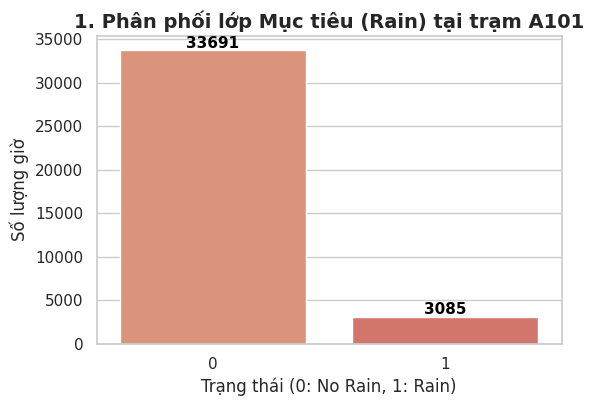

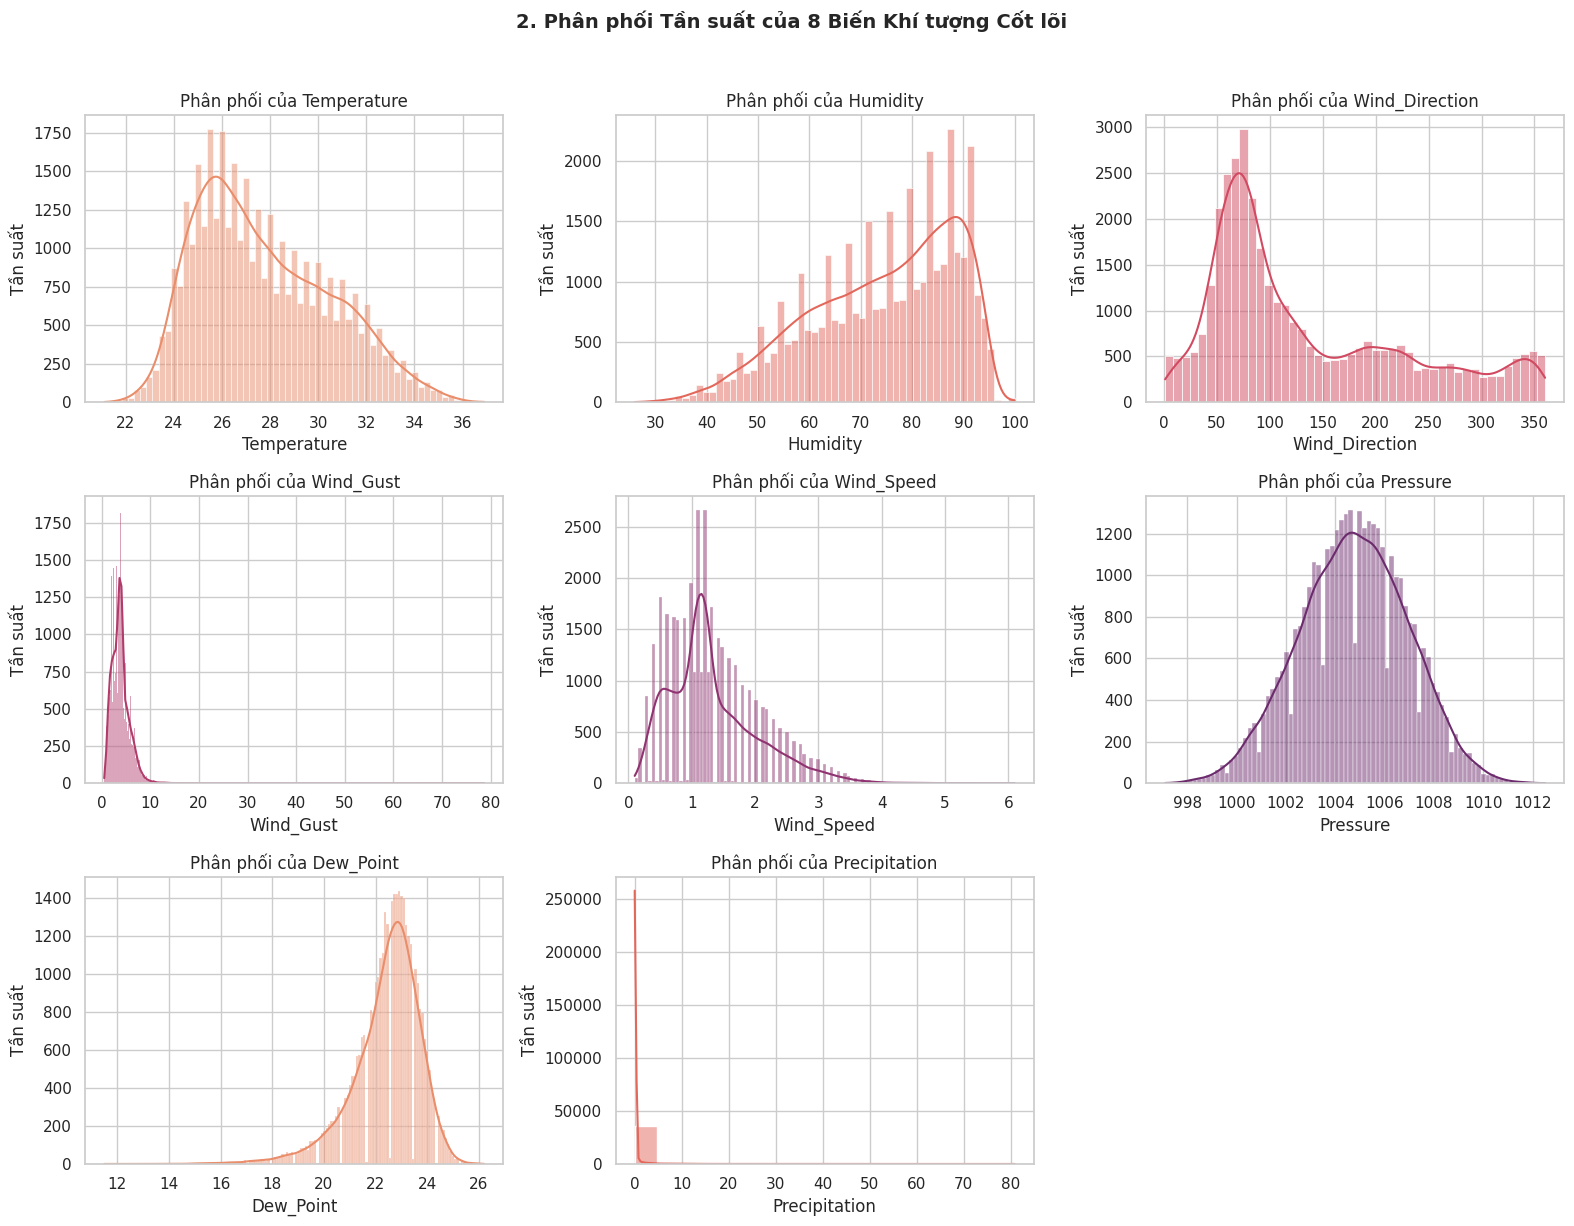

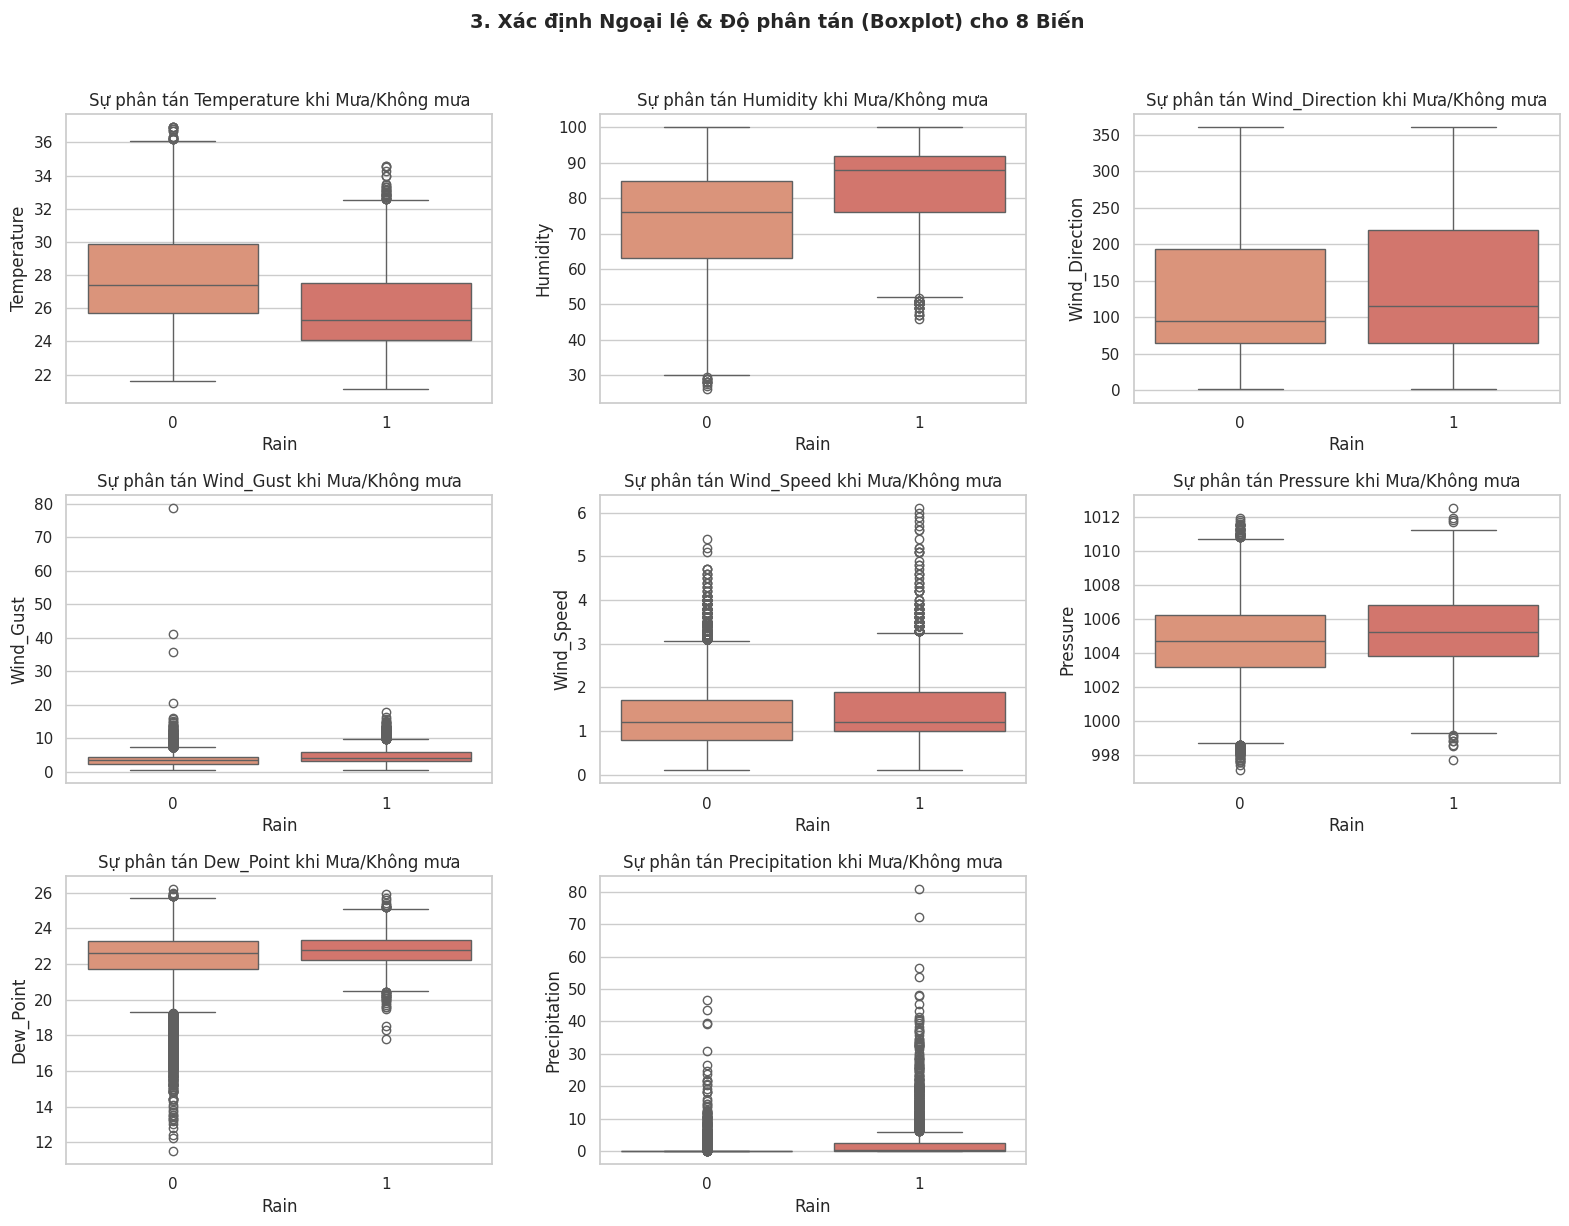

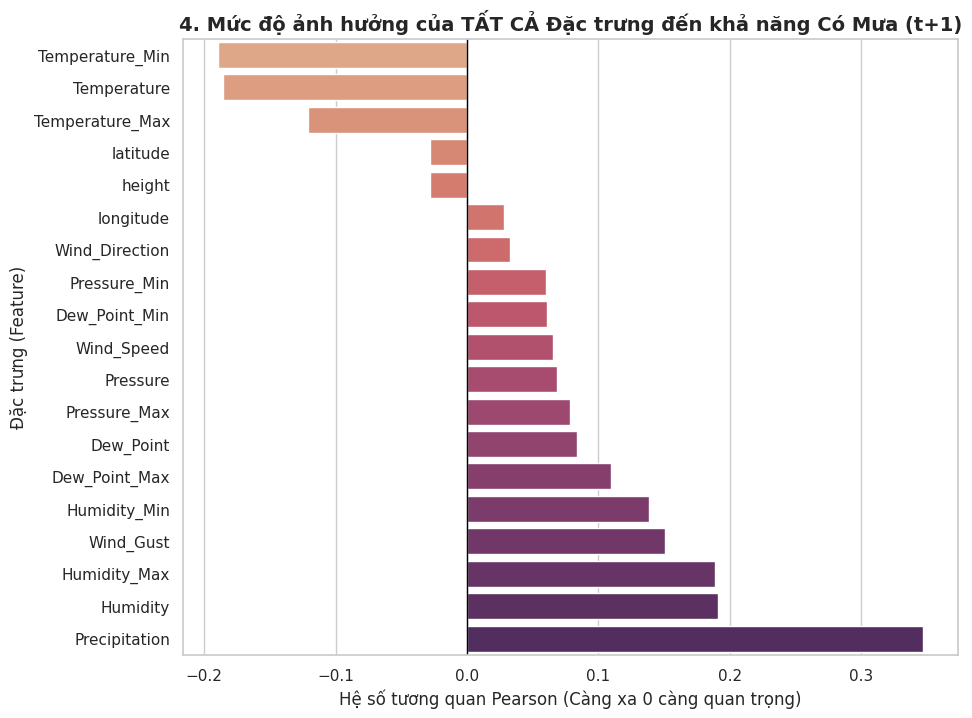

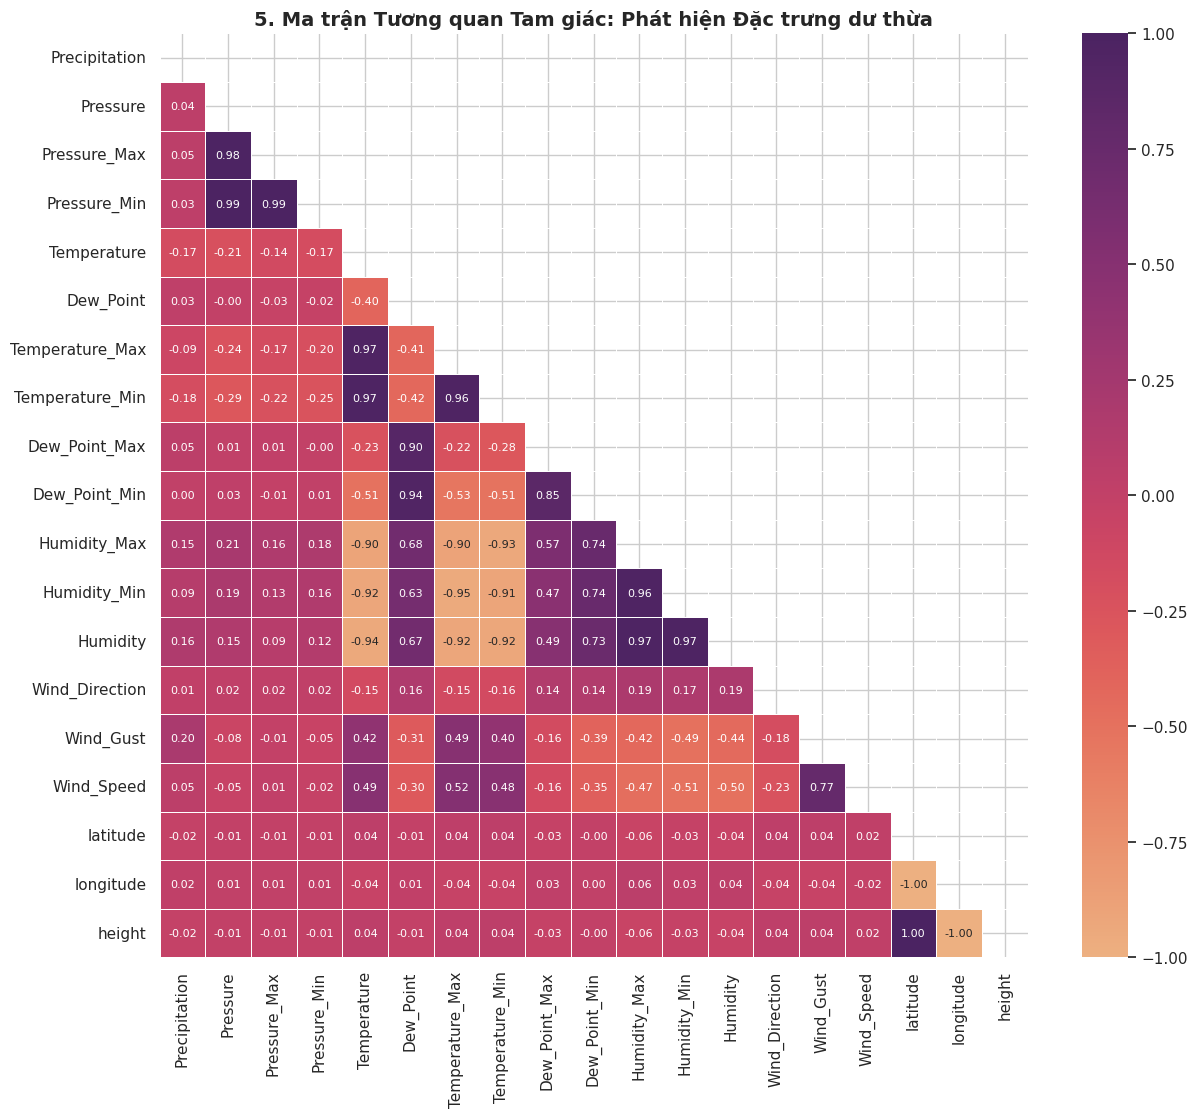


--- KIỂM TRA CHÍNH XÁC HỆ SỐ TƯƠNG QUAN BẰNG SỐ ---
Danh sách các cặp Đa cộng tuyến (|r| > 0.9) CẦN XÓA BỚT:
   - height & latitude: 1.0000
   - Pressure_Min & Pressure_Max: 0.9867
   - Pressure_Min & Pressure: 0.9858
   - Pressure_Max & Pressure: 0.9817
   - Temperature_Min & Temperature: 0.9721
   - Humidity & Humidity_Min: 0.9701
   - Humidity & Humidity_Max: 0.9695
   - Temperature_Max & Temperature: 0.9684
   - Temperature_Min & Temperature_Max: 0.9568
   - Humidity_Min & Humidity_Max: 0.9564
   - Dew_Point_Min & Dew_Point: 0.9405
   - Dew_Point_Max & Dew_Point: 0.9003
   - Humidity_Max & Temperature: -0.9045
   - Humidity_Min & Temperature_Min: -0.9125
   - Humidity_Min & Temperature: -0.9170
   - Humidity & Temperature_Max: -0.9193
   - Humidity & Temperature_Min: -0.9219
   - Humidity_Max & Temperature_Min: -0.9331
   - Humidity & Temperature: -0.9400
   - Humidity_Min & Temperature_Max: -0.9468
   - height & longitude: -1.0000
   - longitude & latitude: -1.0000


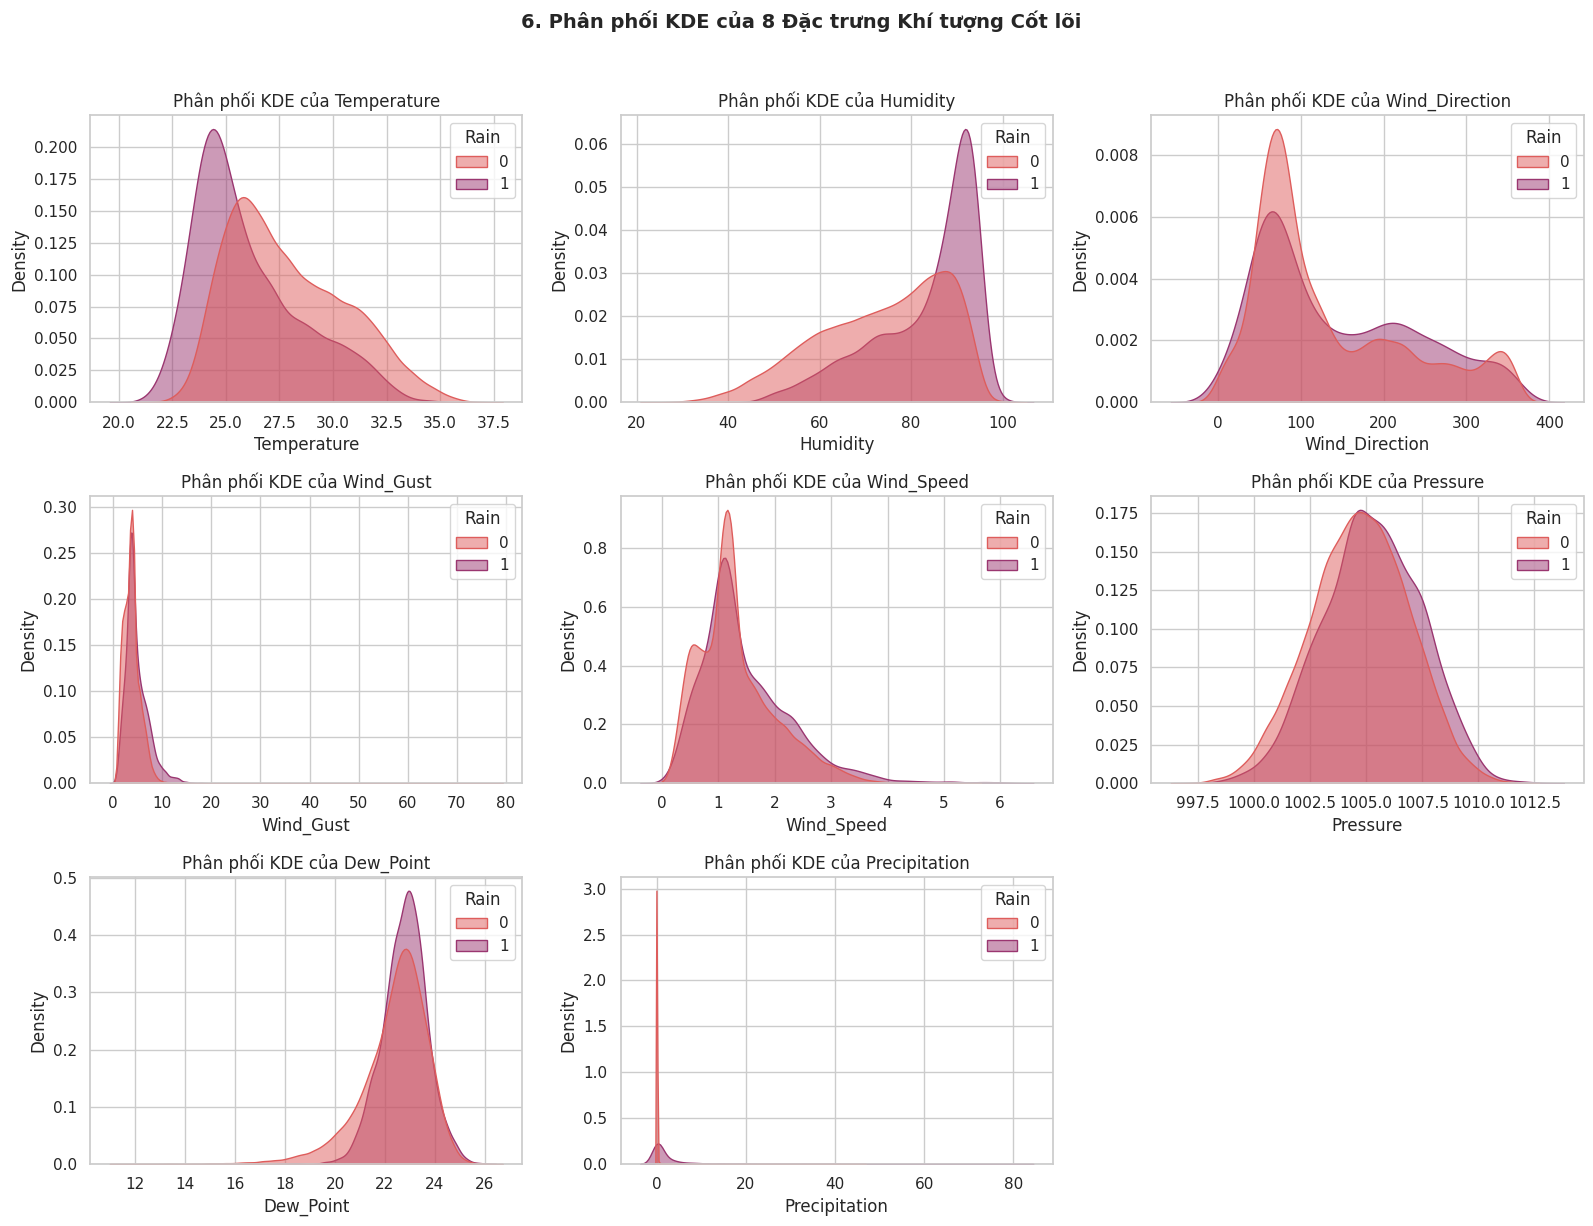


Đang vẽ biểu đồ Chuỗi thời gian cho 4 biến... (Có thể mất một chút thời gian)


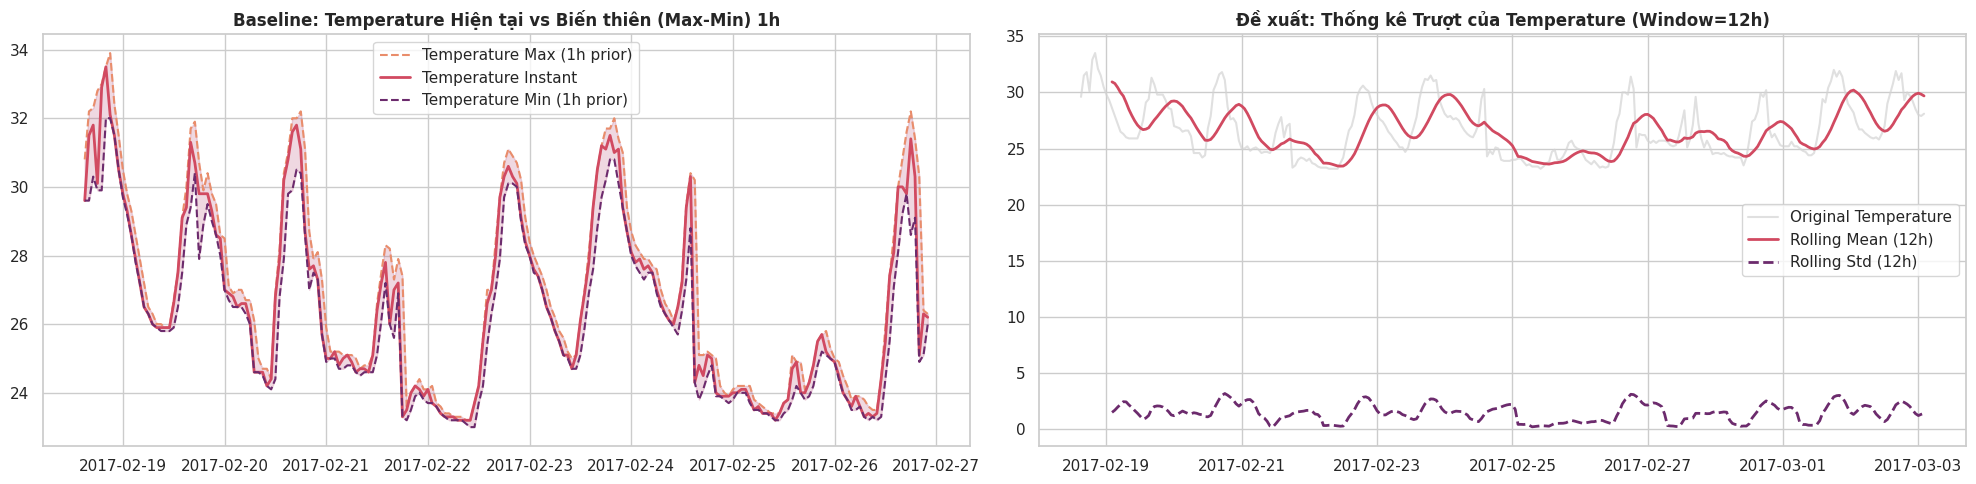

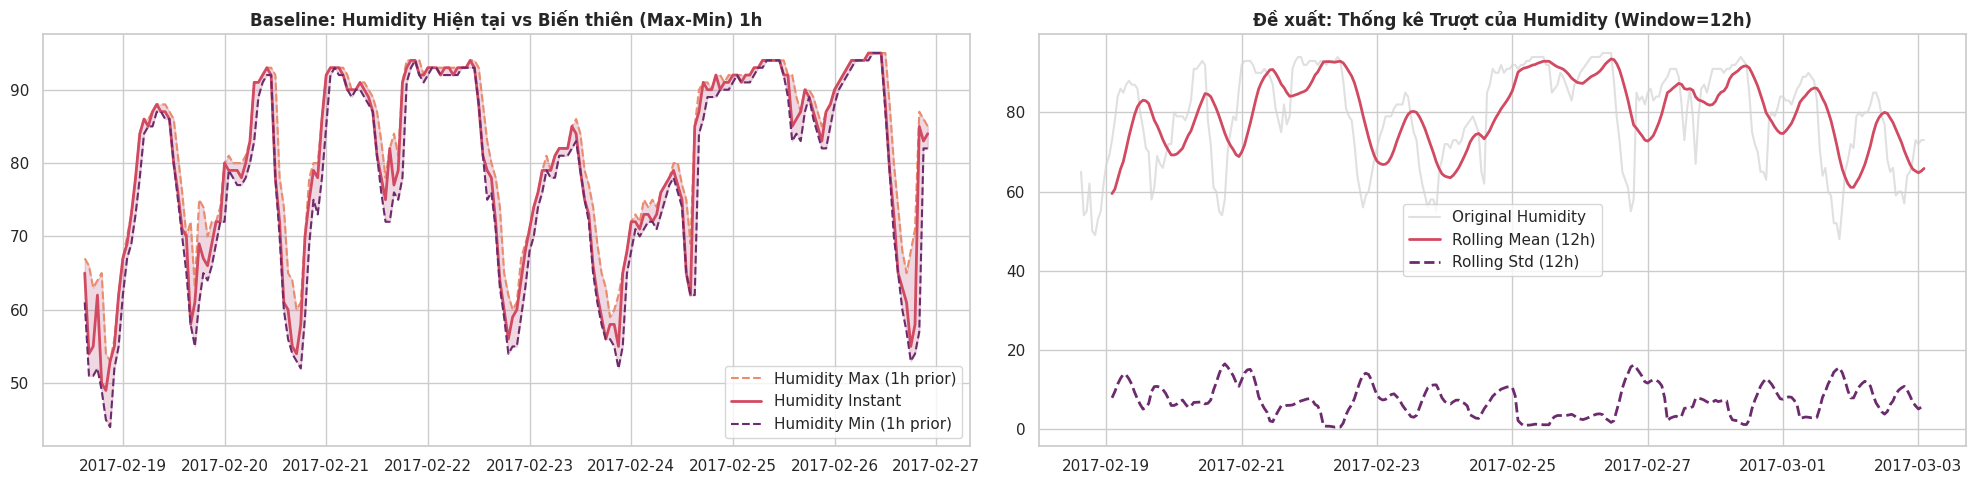

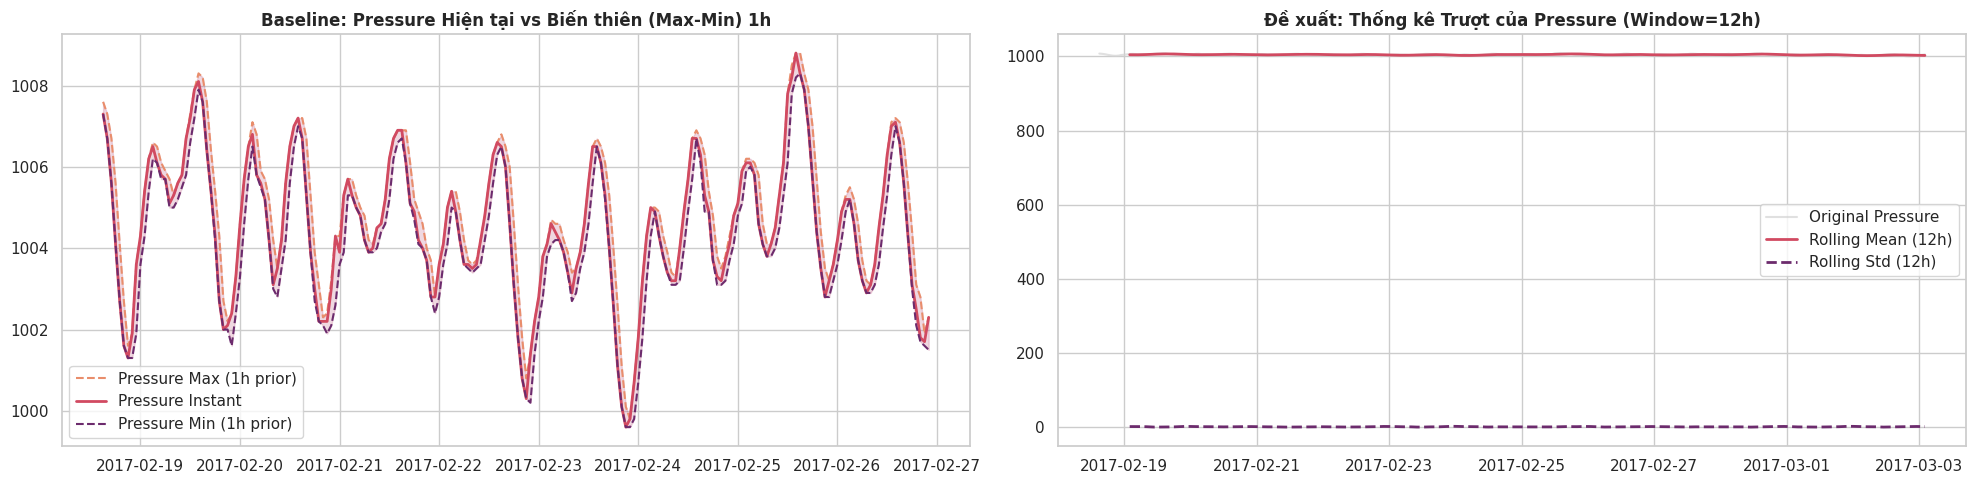

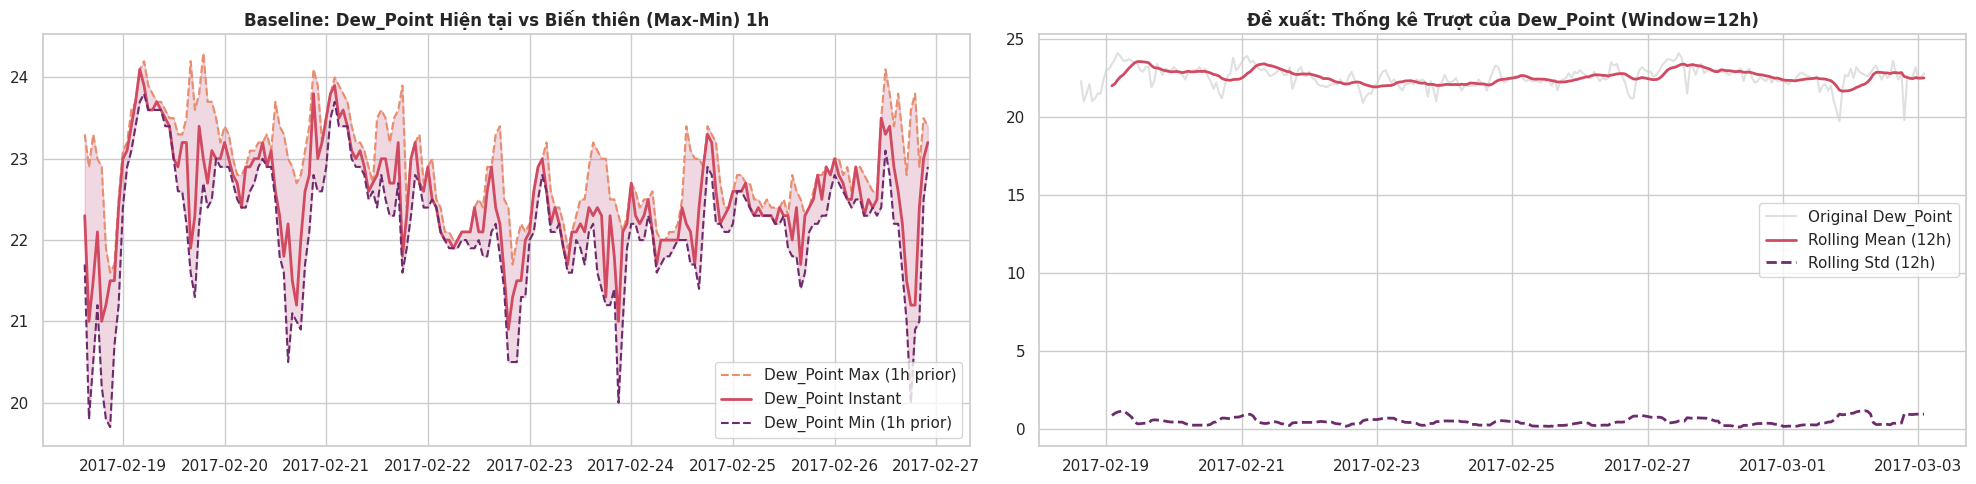

In [ ]:
# ==============================================================================
# PHẦN 2: PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA TRỰC QUAN - THEME FLARE)
# ==============================================================================
sns.set_theme(style="whitegrid")
warm_palette = sns.color_palette("flare")
heat_cmap = sns.color_palette("flare", as_cmap=True)

print("\n--- BẮT ĐẦU VẼ BIỂU ĐỒ ---")

# Tính toán linh hoạt số hàng/cột cho biểu đồ dựa trên số lượng core_features
num_features = len(core_features)
num_cols = 3
num_rows = (num_features + num_cols - 1) // num_cols  # Tự động tính số hàng cần thiết

# ------------------------------------------------------------------------------
# 1. Phân phối lớp Mục tiêu (Có ghi số lượng)
# ------------------------------------------------------------------------------
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df_clean, x='Rain', palette=warm_palette)
plt.title('1. Phân phối lớp Mục tiêu (Rain) tại trạm A101', fontsize=14, fontweight='bold')
plt.xlabel('Trạng thái (0: No Rain, 1: Rain)')
plt.ylabel('Số lượng giờ')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black', fontweight='bold')
plt.show()

# ------------------------------------------------------------------------------
# 2. Phân phối của biến số học cốt lõi (Histogram) - LƯỚI TỰ ĐỘNG
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, 4 * num_rows))
axes = axes.flatten()

for i, col in enumerate(core_features):
    sns.histplot(df_clean[col].dropna(), kde=True, ax=axes[i], color=warm_palette[i % len(warm_palette)])
    axes[i].set_title(f'Phân phối của {col}', fontsize=12)
    axes[i].set_ylabel('Tần suất')

# Xóa các ô trống dư thừa (nếu có)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f"2. Phân phối Tần suất của {num_features} Biến Khí tượng Cốt lõi", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 3. Kiểm tra Ngoại lệ & Độ phân tán (Boxplot) - LƯỚI TỰ ĐỘNG
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, 4 * num_rows))
axes = axes.flatten()

for i, col in enumerate(core_features):
    sns.boxplot(x='Rain', y=col, data=df_clean, ax=axes[i], palette=warm_palette)
    axes[i].set_title(f'Sự phân tán {col} khi Mưa/Không mưa', fontsize=12)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f"3. Xác định Ngoại lệ & Độ phân tán (Boxplot) cho {num_features} Biến", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# CHUẨN BỊ CHO BƯỚC 4 & 5: TÍNH TƯƠNG QUAN TRÊN TẤT CẢ CÁC BIẾN SỐ
# ------------------------------------------------------------------------------
numeric_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()
# Đã xóa 'Precipitation' khỏi danh sách loại trừ vì đây là bài toán t+1
features_to_analyze = [col for col in numeric_cols if col not in ['Rain']]
corr_with_target = df_clean[features_to_analyze + ['Rain']].corr()['Rain'].drop('Rain').sort_values()

# ------------------------------------------------------------------------------
# 4. Tìm ra "Ngôi Sao" (Barplot)
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 8))
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette="flare")
plt.title("4. Mức độ ảnh hưởng của TẤT CẢ Đặc trưng đến khả năng Có Mưa (t+1)", fontsize=14, fontweight='bold')
plt.xlabel("Hệ số tương quan Pearson (Càng xa 0 càng quan trọng)")
plt.ylabel("Đặc trưng (Feature)")
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.show()

# ------------------------------------------------------------------------------
# 5. Phát hiện Dư thừa dữ liệu (Triangular Heatmap)
# ------------------------------------------------------------------------------
plt.figure(figsize=(14, 12))
corr_matrix = df_clean[features_to_analyze].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap=heat_cmap, fmt=".2f",
            linewidths=.5, vmin=-1, vmax=1, annot_kws={"size": 8})
plt.title("5. Ma trận Tương quan Tam giác: Phát hiện Đặc trưng dư thừa", fontsize=14, fontweight='bold')
plt.show()

print("\n--- KIỂM TRA CHÍNH XÁC HỆ SỐ TƯƠNG QUAN BẰNG SỐ ---")
lower_triangle = corr_matrix.where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
corr_pairs = lower_triangle.stack()
high_corr = corr_pairs[corr_pairs.abs() > 0.9].sort_values(ascending=False)

print("Danh sách các cặp Đa cộng tuyến (|r| > 0.9) CẦN XÓA BỚT:")
if high_corr.empty:
    print("   -> Không có cặp biến nào vượt ngưỡng 0.9.")
else:
    for (feat1, feat2), val in high_corr.items():
        print(f"   - {feat1} & {feat2}: {val:.4f}")

# ------------------------------------------------------------------------------
# 6. Kiểm tra phân phối (KDE Plot) - LƯỚI TỰ ĐỘNG
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, 4 * num_rows))
axes = axes.flatten()

for i, col in enumerate(core_features):
    clean_data = df_clean.dropna(subset=[col, 'Rain'])
    sns.kdeplot(data=clean_data, x=col, hue='Rain', fill=True, common_norm=False,
                palette="flare", ax=axes[i], alpha=0.5)
    axes[i].set_title(f'Phân phối KDE của {col}', fontsize=12)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f"6. Phân phối KDE của {num_features} Đặc trưng Khí tượng Cốt lõi", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 7. Phân tích Cửa sổ thời gian (Baseline Max/Min vs Rolling Window)
# ------------------------------------------------------------------------------
time_series_features = ['Temperature', 'Humidity', 'Pressure', 'Dew_Point']
window_size = 12

print("\nĐang vẽ biểu đồ Chuỗi thời gian cho 4 biến... (Có thể mất một chút thời gian)")

for col in time_series_features:
    col_max = f"{col}_Max"
    col_min = f"{col}_Min"

    fig, axes = plt.subplots(1, 2, figsize=(20, 5))
    subset_df = df_clean.head(200).dropna(subset=[col, col_max, col_min])

    axes[0].plot(subset_df.index, subset_df[col_max], label=f'{col} Max (1h prior)', color=warm_palette[0], linestyle='--')
    axes[0].plot(subset_df.index, subset_df[col], label=f'{col} Instant', color=warm_palette[2], linewidth=2)
    axes[0].plot(subset_df.index, subset_df[col_min], label=f'{col} Min (1h prior)', color=warm_palette[5], linestyle='--')
    axes[0].fill_between(subset_df.index, subset_df[col_min], subset_df[col_max], color=warm_palette[3], alpha=0.2)
    axes[0].set_title(f"Baseline: {col} Hiện tại vs Biến thiên (Max-Min) 1h", fontsize=12, fontweight='bold')
    axes[0].legend()

    subset_rolling = df_clean.head(300)
    rolling_mean = subset_rolling[col].rolling(window=window_size).mean()
    rolling_std = subset_rolling[col].rolling(window=window_size).std()

    axes[1].plot(subset_rolling.index, subset_rolling[col], label=f'Original {col}', color='lightgray', alpha=0.7)
    axes[1].plot(subset_rolling.index, rolling_mean, label=f'Rolling Mean ({window_size}h)', color=warm_palette[2], linewidth=2)
    axes[1].plot(subset_rolling.index, rolling_std, label=f'Rolling Std ({window_size}h)', color=warm_palette[5], linewidth=2, linestyle='--')
    axes[1].set_title(f"Đề xuất: Thống kê Trượt của {col} (Window={window_size}h)", fontsize=12, fontweight='bold')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# Preprocessing

In [ ]:
# ==============================================================================
# BƯỚC 2: DATA REDUCTION (Giảm chiều dữ liệu - Lựa chọn tập thuộc tính)
# Căn cứ: Attribute subset selection - Loại bỏ các thuộc tính dư thừa/không liên quan
# Dựa trên phân tích tương quan (Correlation analysis) từ bước EDA .
# ==============================================================================

# 2. Định nghĩa các cột cần loại bỏ dựa trên bằng chứng Heatmap:
columns_to_drop = [
    # Dư thừa (Redundancy r > 0.9): Các cột Max/Min do INMET tính sẵn
    'Temperature_Max', 'Temperature_Min', 'Dew_Point_Max', 'Dew_Point_Min',
    'Humidity_Max', 'Humidity_Min', 'Pressure_Max', 'Pressure_Min',

    # Không liên quan (Irrelevant): Metadata của trạm
    'region', 'state', 'station', 'station_code', 'latitude', 'longitude', 'height'
]

df_reduced = df_clean.drop(columns=columns_to_drop, errors='ignore')

print(f"3. Đã hoàn thành Data Reduction. Kích thước tập dữ liệu sau khi giảm chiều: {df_reduced.shape}")

3. Đã hoàn thành Data Reduction. Kích thước tập dữ liệu sau khi giảm chiều: (36776, 9)


In [ ]:
# ==============================================================================
# BƯỚC 3: DATA TRANSFORMATION - NORMALIZATION (Chuẩn hóa dữ liệu)
# ==============================================================================
scaler = StandardScaler()

current_numeric_cols = df_reduced.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Cột 'Rain' là biến mục tiêu (0 và 1), không được chuẩn hóa.
features_to_scale = [col for col in current_numeric_cols if col not in ['Rain']]

# Áp dụng công thức Z-score lên các cột còn lại
df_reduced[features_to_scale] = scaler.fit_transform(df_reduced[features_to_scale])

print("4. Đã hoàn thành Data Transformation: Chuẩn hóa Z-score.")

4. Đã hoàn thành Data Transformation: Chuẩn hóa Z-score.


In [ ]:
y_rain = df_reduced.pop('Rain')
display(y_rain.head())

,Rain
Datetime,
2017-02-18 15:00:00,0
2017-02-18 16:00:00,0
2017-02-18 17:00:00,0
2017-02-18 18:00:00,0
2017-02-18 19:00:00,0


In [ ]:
from sklearn.model_selection import train_test_split
from google.colab import files

print("--- BẮT ĐẦU CHIA TẬP ---")

# Lưu ý: shuffle=False rất chuẩn xác cho dữ liệu chuỗi thời gian (Time-series)
df_train, df_test = train_test_split(df_reduced, test_size=0.2, shuffle=False)
y_train, y_test = train_test_split(y_rain, test_size=0.2, shuffle=False)

# Đã thêm chữ 'f' ở đầu chuỗi để format hiển thị đúng giá trị
print(f"\n Kích thước tập train X (80%): {df_train.shape} - Từ {df_train.index.min()} đến {df_train.index.max()}")
print(f" Kích thước tập test X (20%): {df_test.shape} - Từ {df_test.index.min()} đến {df_test.index.max()}")
print(f"\n Kích thước nhãn train y (80%): {y_train.shape} - Từ {y_train.index.min()} đến {y_train.index.max()}")
print(f" Kích thước nhãn test y (20%): {y_test.shape} - Từ {y_test.index.min()} đến {y_test.index.max()}")

df_train_filename = 'df_train_preprocessed.csv'
df_test_filename = 'df_test_preprocessed.csv'
y_train_filename = 'y_train_preprocessed.csv'
y_test_filename = 'y_test_preprocessed.csv'

print("\n--- BẮT ĐẦU LƯU VÀ TẢI FILE VỀ MÁY ---")

# 1. Xuất DataFrame/Series ra file CSV lưu tạm trên hệ thống của Google Colab
df_train.to_csv(df_train_filename)
df_test.to_csv(df_test_filename)
y_train.to_csv(y_train_filename)
y_test.to_csv(y_test_filename)

# 2. Kích hoạt trình duyệt tải các file đó về máy tính cá nhân
files.download(df_train_filename)
files.download(df_test_filename)
files.download(y_train_filename)
files.download(y_test_filename)

--- BẮT ĐẦU CHIA TẬP ---

 Kích thước tập train X (80%): (29420, 8) - Từ 2017-02-18 15:00:00 đến 2020-06-28 10:00:00
 Kích thước tập test X (20%): (7356, 8) - Từ 2020-06-28 11:00:00 đến 2021-04-30 22:00:00

 Kích thước nhãn train y (80%): (29420,) - Từ 2017-02-18 15:00:00 đến 2020-06-28 10:00:00
 Kích thước nhãn test y (20%): (7356,) - Từ 2020-06-28 11:00:00 đến 2021-04-30 22:00:00

--- BẮT ĐẦU LƯU VÀ TẢI FILE VỀ MÁY ---


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_train.tail(10)

,Precipitation,Pressure,Temperature,Dew_Point,Humidity,Wind_Direction,Wind_Gust,Wind_Speed
Datetime,,,,,,,,
2020-06-28 01:00:00,-0.137082,-0.201861,0.172643,0.444443,-0.100082,-0.889662,-0.620750,-0.880752
2020-06-28 02:00:00,-0.137082,0.116428,0.064568,0.890088,0.255383,-1.125927,-1.115199,-1.165782
2020-06-28 03:00:00,-0.137082,0.116428,-0.043507,1.112910,0.397569,-0.835965,-1.170138,-0.595722
2020-06-28 04:00:00,-0.137082,-0.065451,-0.295682,1.187184,0.681941,2.332139,-1.170138,-1.165782
2020-06-28 05:00:00,-0.137082,-0.247331,-0.151582,1.261458,0.610848,-0.707093,-1.225076,-0.595722
2020-06-28 06:00:00,-0.137082,-0.406476,-0.349719,1.001499,0.681941,-0.825226,-1.115199,-0.809495
2020-06-28 07:00:00,-0.137082,-0.565620,-0.547857,0.741540,0.753034,-0.943359,-1.005322,-1.023267
2020-06-28 08:00:00,-0.137082,-0.702030,-0.655932,0.741540,0.824127,-0.803747,-1.060260,-0.738237
2020-06-28 09:00:00,-0.137082,-0.565620,-0.619907,0.890088,0.895220,-0.610439,-1.280015,-0.880752
